In [ ]:
import numpy as np
import math as ma
import matplotlib.pyplot as plt
from scipy.special import eval_hermite
import scipy.constants as cnst

In [ ]:
eV = cnst.eV
h_c = cnst.hbar
m_e = cnst.m_e
L = 1e-9
ω = 1e15

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import sys

sys.path.append('/content/drive/My Drive/Colab Notebooks')
from fdm_solver import fdm_schrodinger
from qm_shooting import Find_eigenvalue
from qm_shooting import wave_shooting

**INFINITE POTENTIAL WELL**

In [ ]:
#Defining the potential.
def well_pot(x, params):
  V = np.zeros_like(x)
  return V

#Parameters
params = {}

1. Analytical method

$$E_n = \frac{n^2 \pi^2 \hbar^2}{2 m a^2}$$ <br>

$$\psi_n(x) = \sqrt{\frac{2}{a}} \sin\left(\frac{n \pi (x)}{a}\right)$$

--- Analytical Solution ---
--- Energy Levels ---
State n=1: Energy 1 = 0.376 eV
State n=2: Energy 1 = 1.504 eV
State n=3: Energy 1 = 3.384 eV


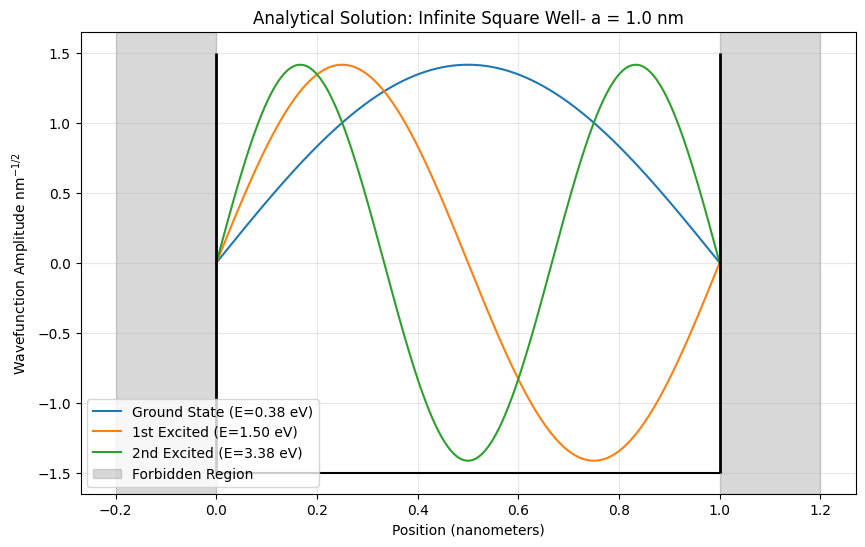

In [ ]:
E_a = []

for n in range(6):
  E = ((n+1)**2)*(np.pi**2)*(h_c**2)/(2*m_e*(L**2)*eV)
  E_a.append(E)

x_a = np.linspace(0,1,1000)


y1 = np.sqrt(2)*np.sin((np.pi*x_a))      # a = 1nm (units of y are (nm)^(-0.5)
y2 = np.sqrt(2)*np.sin((2*np.pi*x_a))
y3 = np.sqrt(2)*np.sin((3*np.pi*x_a))



print("--- Analytical Solution ---")
print("--- Energy Levels ---")

for n in range(3):
  print(f"State n={n+1}: Energy 1 = {E_a[n]:.3f} eV")

plt.figure(figsize=(10, 6))
plt.plot(x_a, y1, label=f"Ground State (E={E_a[0]:.2f} eV)")
plt.plot(x_a, y2, label=f"1st Excited (E={E_a[1]:.2f} eV)")
plt.plot(x_a, y3, label=f"2nd Excited (E={E_a[2]:.2f} eV)")
x_start = 0 #nm
x_end = 1 #nm
plt.title(f"Analytical Solution: Infinite Square Well- a = {L*1e9} nm")
plt.xlabel("Position (nanometers)")
plt.ylabel(r"Wavefunction Amplitude $\text{nm}^{-1/2}$")
plt.hlines(y = -1.5, xmin= x_start, xmax = x_end, color='black', linestyle='-')
plt.vlines(x=[x_start, x_end], ymin=-1.5, ymax=1.5, color='black', linewidth=2)
plt.axvspan(xmin=x_start - 0.2, xmax=x_start, color='gray', alpha=0.3, label="Forbidden Region")
plt.axvspan(xmin=x_end, xmax=x_end + 0.2, color='gray', alpha=0.3)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

2. Finite Difference Method Solver

--- FDM ---
--- Energy Levels ---
State n=1: Energy=0.376 eV
State n=2: Energy=1.504 eV
State n=3: Energy=3.384 eV


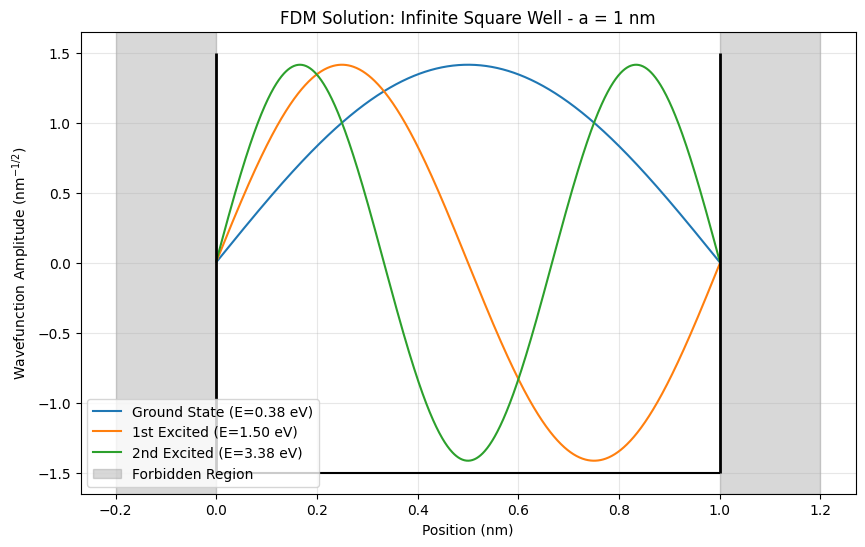

In [ ]:
x_start = 0 #nm
x_end = 1 #nm
N = 1000

Energy_fdm, ψ, x_fdm = fdm_schrodinger(x_start, x_end, N, well_pot, params = params)

print("--- FDM ---")
print("--- Energy Levels ---")
for n in range(3):
    print(f"State n={n+1}: Energy={Energy_fdm[n]:.3f} eV")

plt.figure(figsize=(10, 6))
plt.plot(x_fdm, ψ[:,0], label=f"Ground State (E={Energy_fdm[0]:.2f} eV)")
plt.plot(x_fdm, -ψ[:, 1], label=f"1st Excited (E={Energy_fdm[1]:.2f} eV)")
plt.plot(x_fdm, -ψ[:, 2], label=f"2nd Excited (E={Energy_fdm[2]:.2f} eV)")

plt.title(f"FDM Solution: Infinite Square Well - a = {x_end - x_start} nm")
plt.xlabel("Position (nm)")
plt.ylabel(r"Wavefunction Amplitude ($\text{nm}^{-1/2}$)")
plt.hlines(y = -1.5, xmin= x_start, xmax = x_end, color='black', linestyle='-')
plt.vlines(x=[x_start, x_end], ymin=-1.5, ymax=1.5, color='black', linewidth=2)
plt.axvspan(xmin=x_start - 0.2, xmax=x_start, color='gray', alpha=0.3, label="Forbidden Region")
plt.axvspan(xmin=x_end, xmax=x_end + 0.2, color='gray', alpha=0.3)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

ψ_fdm = ψ[:,0]

3. Shooting method

--- Shooting Method ---
--- Energy Levels ---
State n=1: Energy=0.376 eV
State n=2: Energy=1.504 eV
State n=3: Energy=3.384 eV


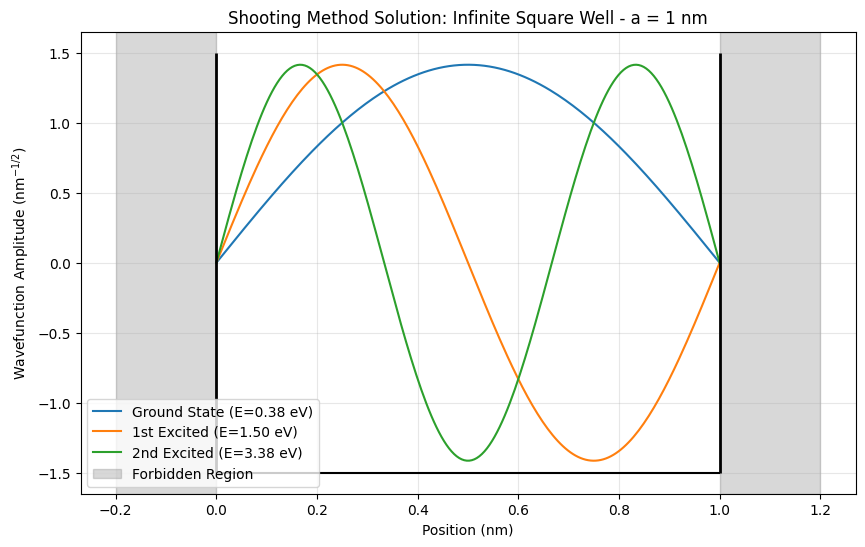

In [ ]:
x_start = 0 #nm
x_end = 1 #nm
N = 1000

soln = wave_shooting(params= params ,V= well_pot, E_1 = 0.3, x_s = 0, x_e =1)
Energy_sm = np.array([soln["Ground State"]["E"], soln["Excited State 1"]["E"], soln["Excited State 2"]["E"], soln["Excited State 3"]["E"], soln["Excited State 4"]["E"], soln["Excited State 5"]["E"]])
ψ =  np.array([soln["Ground State"]["Pi"], soln["Excited State 1"]["Pi"], soln["Excited State 2"]["Pi"]])
x_sm=  np.array(soln["Ground State"]["x"])

print("--- Shooting Method ---")
print("--- Energy Levels ---")
for n in range(3):
    print(f"State n={n+1}: Energy={Energy_sm[n]:.3f} eV")


plt.figure(figsize=(10, 6))
plt.plot(x_sm, ψ[0], label=f"Ground State (E={Energy_sm[0]:.2f} eV)")
plt.plot(x_sm, ψ[1], label=f"1st Excited (E={Energy_sm[1]:.2f} eV)")
plt.plot(x_sm, ψ[2], label=f"2nd Excited (E={Energy_sm[2]:.2f} eV)")

plt.title(f"Shooting Method Solution: Infinite Square Well - a = {x_end - x_start} nm")
plt.xlabel("Position (nm)")
plt.ylabel(r"Wavefunction Amplitude ($\text{nm}^{-1/2}$)")
plt.hlines(y = -1.5, xmin= x_start, xmax = x_end, color='black', linestyle='-')
plt.vlines(x=[x_start, x_end], ymin=-1.5, ymax=1.5, color='black', linewidth=2)
plt.axvspan(xmin=x_start - 0.2, xmax=x_start, color='gray', alpha=0.3, label="Forbidden Region")
plt.axvspan(xmin=x_end, xmax=x_end + 0.2, color='gray', alpha=0.3)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

ψ_sm = ψ[0]

**HARMONIC OSCILATOR**

1. Analytical method

--- Analytical Energy Levels ---
State n=0: 0.32911 eV
State n=1: 0.98732 eV
State n=2: 1.64553 eV


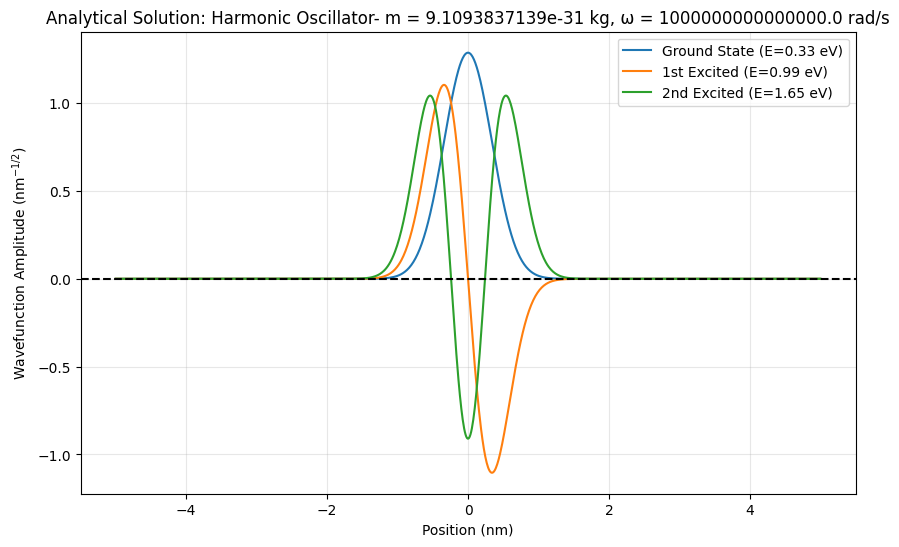

In [ ]:
alpha = np.sqrt(m_e * ω / h_c)*1e-9   # alpha in (nm)^(-1/2)
E_ho = []

def Energy_HO(n):
    """Calculates the exact energy of state n in eV."""
    E_joules = h_c * ω * (n + 0.5)
    return E_joules / eV

def Wavefunction(n, x):
    # Normalization constant
    N_n = (1.0 / ma.sqrt((2**n) * ma.factorial(n))) * (alpha**2 / np.pi)**0.25

    # The Gaussian envelope
    gaussian = np.exp(-0.5 * (alpha * x)**2)

    # The Hermite Polynomial
    hermite = eval_hermite(n, alpha * x)

    return (-1)**n*N_n * hermite * gaussian

x_HO = np.linspace(-5, 5, 1000)    # in nms

print("--- Analytical Energy Levels ---")
for n in range(3):
    print(f"State n={n}: {Energy_HO(n):.5f} eV")

for n in range(6):
    E_ho.append(Energy_HO(n))

# Plotting the first three states
plt.figure(figsize=(10, 6))
plt.plot(x_HO, Wavefunction(0, x_axis), label=f"Ground State (E={Energy_HO(0):.2f} eV)")
plt.plot(x_HO, Wavefunction(1, x_axis), label=f"1st Excited (E={Energy_HO(1):.2f} eV)")
plt.plot(x_HO, Wavefunction(2, x_axis), label=f"2nd Excited (E={Energy_HO(2):.2f} eV)")

plt.title(f"Analytical Solution: Harmonic Oscillator- m = {m_e} kg, ω = {ω} rad/s")
plt.xlabel("Position (nm)")
plt.ylabel(r"Wavefunction Amplitude ($\text{nm}^{-1/2}$)")
plt.axhline(0, color='black', linestyle='--')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

2. Finite Difference Method Solver

In [ ]:
#Defining the potential.
def harmonic_V(x, params):
    m = params.get('m', m_e)
    ω = params.get('ω', 1e15)
    V = 0.5*m*ω**2*x**2
    return V

params = {}

--- FDM ---
--- Energy Levels ---
State n=1: Energy=0.32924 eV
State n=2: Energy=0.98771 eV
State n=3: Energy=1.64618 eV


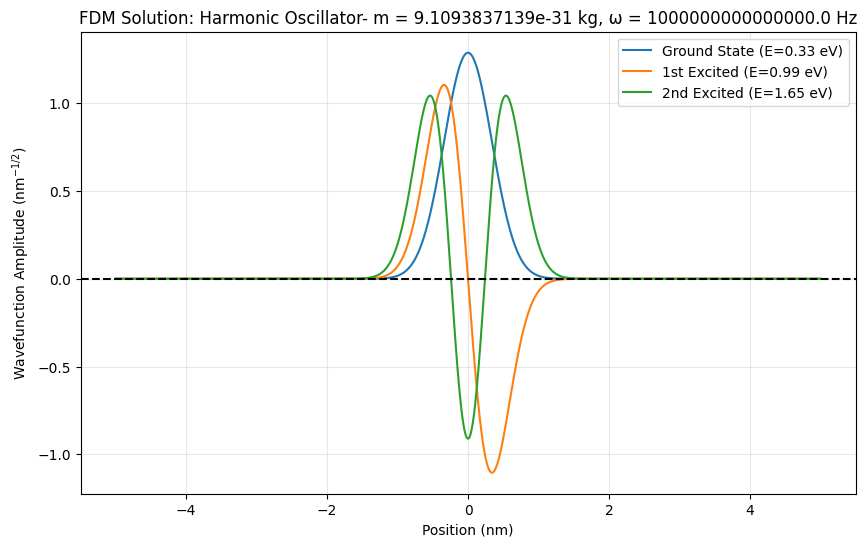

In [ ]:
x_s = -5 #nm
x_e = 5 #nm
N = 5000

Energy_fho, ψ, x_FHO = fdm_schrodinger(x_s, x_e, N, harmonic_V, params = params)

print("--- FDM ---")
print("--- Energy Levels ---")
for n in range(3):
    print(f"State n={n+1}: Energy={Energy_fho[n]:.5f} eV")

plt.figure(figsize=(10, 6))
plt.plot(x_FHO, ψ[:,0], label=f"Ground State (E={Energy_fho[0]:.2f} eV)")
plt.plot(x_FHO, ψ[:, 1], label=f"1st Excited (E={Energy_fho[1]:.2f} eV)")
plt.plot(x_FHO, ψ[:, 2], label=f"2nd Excited (E={Energy_fho[2]:.2f} eV)")

plt.title(f"FDM Solution: Harmonic Oscillator- m = {m_e} kg, ω = {ω} Hz")
plt.xlabel("Position (nm)")
plt.ylabel(r"Wavefunction Amplitude ($\text{nm}^{-1/2}$)")
plt.axhline(0, color='black', linestyle='--')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

psih = ψ[:,0]

3. Shooting Method solver

In [ ]:
#Defining the potential.
def harmonic_V_2(x_nm, params):
    x_m = x_nm*1e-9
    m = params.get('m', m_e)
    ω = params.get('ω', 1e15)
    V = 0.5*m*ω**2*x_m**2
    return V/eV

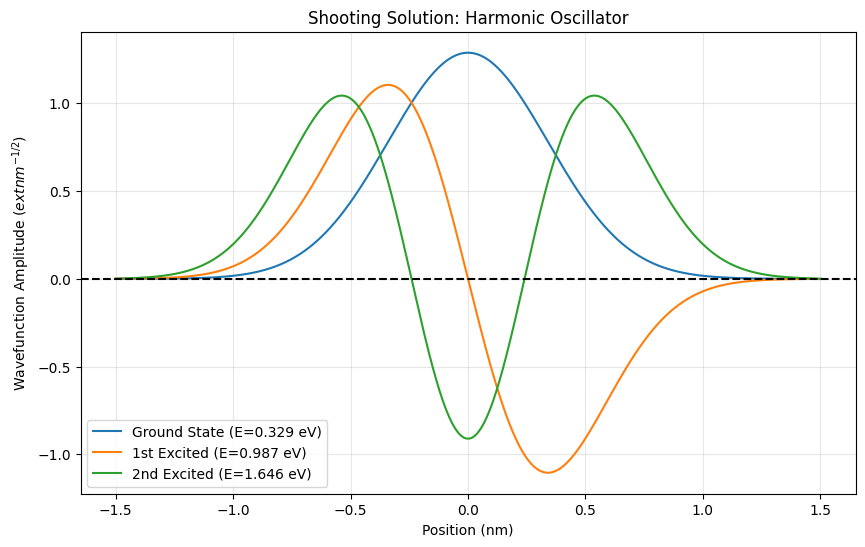

In [ ]:
x_st = -1.5 #nm
x_en = 1.5 #nm
N = 5000

soln= wave_shooting(x_s=x_st,x_e= x_en, N= N, V =harmonic_V_2, params = params, E_1 = 0.3)
Energy_sho = np.array([soln["Ground State"]["E"], soln["Excited State 1"]["E"], soln["Excited State 2"]["E"], soln["Excited State 3"]["E"], soln["Excited State 4"]["E"], soln["Excited State 5"]["E"]])
ψ =  np.array([soln["Ground State"]["Pi"], soln["Excited State 1"]["Pi"], soln["Excited State 2"]["Pi"]])
x_SHO =  np.array(soln["Ground State"]["x"])

plt.figure(figsize=(10, 6))
plt.plot(x_SHO, ψ[0], label=f"Ground State (E={Energy_sho[0]:.3f} eV)")
plt.plot(x_SHO, ψ[1], label=f"1st Excited (E={Energy_sho[1]:.3f} eV)")
plt.plot(x_SHO, ψ[2], label=f"2nd Excited (E={Energy_sho[2]:.3f} eV)")

plt.title("Shooting Solution: Harmonic Oscillator")
plt.xlabel("Position (nm)")
plt.ylabel("Wavefunction Amplitude ($\text{nm}^{-1/2}$)")
plt.axhline(0, color='black', linestyle='--')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

psio = ψ[0]

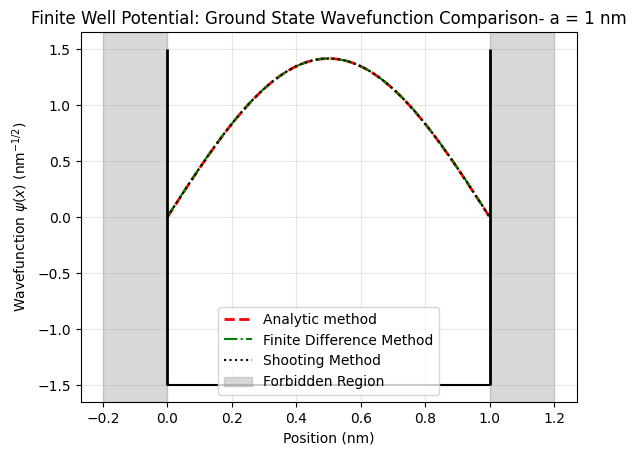

In [ ]:
x_a = np.linspace(0,1,999)
y1 = np.sqrt(2)*np.sin(np.pi*x_a)

plt.plot(x_a, y1, label="Analytic method", color='red', linewidth=2, linestyle='--')
plt.plot(x_fdm, ψ_fdm, label="Finite Difference Method", color='green', linestyle='-.')
plt.plot(x_sm, ψ_sm, label="Shooting Method",  color='black', linestyle=':')
plt.title(f"Finite Well Potential: Ground State Wavefunction Comparison- a = {x_end - x_start} nm")
plt.ylabel(r"Wavefunction $\psi(x)$ ($\text{nm}^{-1/2}$)")
plt.xlabel("Position (nm)")
plt.hlines(y = -1.5, xmin= x_start, xmax = x_end, color='black', linestyle='-')
plt.vlines(x=[x_start, x_end], ymin=-1.5, ymax=1.5, color='black', linewidth=2)
plt.axvspan(xmin=x_start - 0.2, xmax=x_start, color='gray', alpha=0.3, label="Forbidden Region")
plt.axvspan(xmin=x_end, xmax=x_end + 0.2, color='gray', alpha=0.3)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

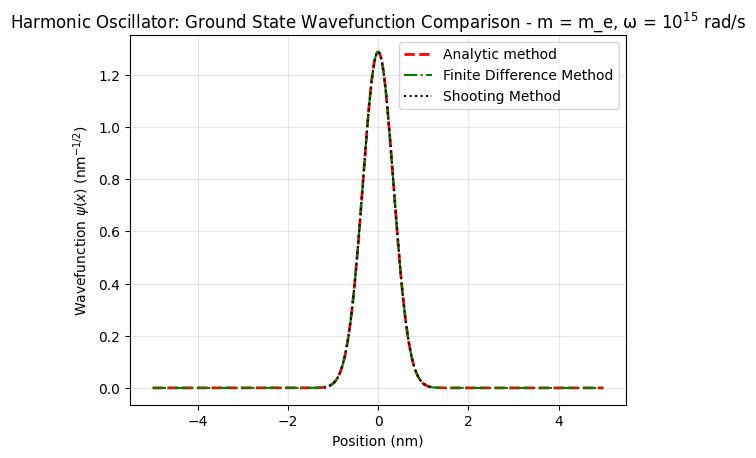

In [ ]:
plt.plot(x_HO, Wavefunction(0, x_HO), label="Analytic method", color='red', linewidth=2, linestyle='--')
plt.plot(x_FHO, psih, label="Finite Difference Method", color='green', linestyle='-.')
plt.plot(x_SHO, psio, label="Shooting Method", color='black', linestyle=':')
plt.title(r"Harmonic Oscillator: Ground State Wavefunction Comparison - m = m_e, ω = $\text{10}^{15}$ rad/s")
plt.ylabel(r"Wavefunction $\psi(x)$ ($\text{nm}^{-1/2}$)")
plt.xlabel("Position (nm)")
plt.legend()
plt.grid(True, alpha=0.3)

In [ ]:
print('---Finite Potential Well---')
print(f'Value of Energies found through Analytical Method: {E_a} eV')
print(f'Value of Energies found through Finite Difference Method: {Energy_fdm[0:6]} eV')
print(f'Value of Energies found through Shooting Method: {Energy_sm[0:6]} eV')
error1 = np.abs((Energy_fdm[0:6]-E_a)/E_a)*100
error2 = np.abs((Energy_sm[0:6]-E_a)/E_a)*100
print(f'Relative error in Finite Difference Method: {error1}')
print(f'Relative error in Shooting Method: {error2}')


---Finite Potential Well---
Value of Energies found through Analytical Method: [0.3760301621048726, 1.5041206484194904, 3.3842714589438536, 6.016482593677962, 9.400754052621815, 13.537085835775414] eV
Value of Energies found through Finite Difference Method: [ 0.37602985  1.5041157   3.38424641  6.01640342  9.40056076 13.53668502] eV
Value of Energies found through Shooting Method: [ 0.37602966  1.50410645  3.38427063  6.01645264  9.40070618 13.53699585] eV
Relative error in Finite Difference Method: [8.22430904e-05 3.28985851e-04 7.40217562e-04 1.31594013e-03
 2.05615051e-03 2.96084616e-03]
Relative error in Shooting Method: [1.32707156e-04 9.44279769e-04 2.44974754e-05 4.97914834e-04
 5.09276850e-04 6.64738093e-04]


In [ ]:
print('---Harmonic Oscillator---')
print(f'Value of Energies found through Analytical Method: {E_ho} eV')
print(f'Value of Energies found through Finite Difference Method: {Energy_fho[0:6]} eV')
print(f'Value of Energies found through Shooting Method: {Energy_sho[0:6]} eV')
err1 = np.abs((Energy_fho[0:6]-E_ho)/E_a)*100
err2 = np.abs((Energy_sho[0:6]-E_ho)/E_a)*100
print(f'Relative error in Finite Difference Method: {err1}')
print(f'Relative error in Shooting Method: {err2}')

---Harmonic Oscillator---
Value of Energies found through Analytical Method: [0.3291059784754533, 0.98731793542636, 1.6455298923772665, 2.303741849328173, 2.96195380627908, 3.6201657632299864] eV
Value of Energies found through Finite Difference Method: [0.32923696 0.98770946 1.64617912 2.30464593 2.9631099  3.62157102] eV
Value of Energies found through Shooting Method: [0.32910583 0.98731812 1.6455365  2.30381958 2.96254211 3.62339844] eV
Relative error in Finite Difference Method: [0.03483332 0.02603041 0.01918371 0.01502678 0.01229788 0.0103808 ]
Relative error in Shooting Method: [3.81656926e-05 1.19543612e-05 1.95216201e-04 1.29196335e-03
 6.25809350e-03 2.38801342e-02]
